![image.png](image\求解函数最小值题目(解是10维).png)

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray

plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 使用微软雅黑
plt.rcParams["axes.unicode_minus"] = False         # 解决负号显示问题

In [36]:
class GA:
    """遗传算法求解函数"""
    def __init__(self, pop_size: int = 100, max_generations: int = 1000, cross_rate: float = 0.8, mutation_rate: float = 0.1):
        """ 
        初始化

        :param pop_size: 种群大小
        :param max_generations: 迭代次数
        :param cross_rate: 交叉概率
        :param mutation_rate: 变异概率   
        """
        # 遗传算法超参数
        self.pop_size=  pop_size
        self.max_generations = max_generations
        self.cross_rate = cross_rate
        self.mutation_rate = mutation_rate

        # 解的形式与区间
        self.dim = 10
        self.x_min = -20   # 变量下限
        self.x_max = 20    # 变量上限

        # 种群与状态变量
        self.population: NDArray[np.float64] = None             # （pop_size, dim)
        self.fitness = None                # 当轮种群每个个体的适应度 pop_size 
        self.best_fitness = float('inf')   # 全局最优适应度(越小越好)
        self.best_ind = None               # 全局最优个体(可行解)
        self.best_fitness_history = []     # 记录每轮最佳的适应度 max_generation

    def initialize_population(self):
        """
        初始化种群(随机, 标准正态分布)
        """
        self.population = np.random.uniform(low=self.x_min, high=self.x_max, size=(self.pop_size, self.dim))
    
    @staticmethod
    def objective_func(ind):
        """
        目标函数
        """
        return np.sum(ind ** 2)


    def evaluate_population(self):
        """
        评估整个种群的适应度, 更新全局最优
        """
        self.fitness = np.array([self.objective_func(ind) for ind in self.population]) # 评估种群适应度

        # 当代最优
        cur_best_idx = np.argmin(self.fitness)
        cur_best_fitness = self.fitness[cur_best_idx]
        cur_best_ind = self.population[cur_best_idx]

        # 更新全局最优
        if cur_best_fitness < self.best_fitness:
            self.best_fitness = cur_best_fitness
            self.best_ind = cur_best_ind
        
        # 记录每轮最优值
        self.best_fitness_history.append(cur_best_fitness)

        

    def selection(self):
        """
        选择, 适应度越小, 选择概率越大
        """
        ad_fitness = 1 / self.fitness                   # 适应度越小越优，将适应度转换为选择概率（取倒数避免负适应度）
        
        probabilities = ad_fitness / np.sum(ad_fitness) # 每个个体的选择概率 
        # choice内部是轮盘赌算法，根据选择概率p计算累积概率
        # a 待选择元素范围
        # size 选择个数
        # replace=True 重复抽样
        selected_indices = np.random.choice(a=self.pop_size, size=self.pop_size, p=probabilities, replace=True)
        selected_pop = self.population[selected_indices]
        return selected_pop
    
    def crossover(self, parent1: np.ndarray, parent2: np.ndarray):
        """ 
        交叉, 随机选一个点交叉

        :param parent1: 父体1 (dim, )
        :param parent2: 父体2 (dim, )
        :return child1: 交叉后的子体1
        :return child2: 交叉后的子体2
        """
        if np.random.rand() < self.cross_rate:             # 交叉
            cross_point = np.random.randint(1, self.dim)   # [1, self.dim)
            child1 = np.concatenate([parent1[:cross_point], parent2[cross_point:]])
            child2 = np.concatenate([parent2[:cross_point], parent1[cross_point:]])
            return child1, child2 
        else: 
            return parent1.copy(), parent2.copy()    
        
    def mutate(self, ind):
        """ 
        变异, 对一个个体的每个基因点概率生成新的值
        """
        for i in range(self.dim):
            if np.random.rand() < self.mutation_rate:
                ind[i] = np.random.uniform(self.x_min, self.x_max)
        
        return ind

    
    def run(self):
        self.initialize_population() # 初始化种群  
        self.evaluate_population()
        for gen in range(self.max_generations):
     
            selected_pop = self.selection()         # 选择种群 

            new_pop = []                            # 交叉、变异生成新种群
            for i in range(0, self.pop_size, 2):    # 每两个父体交叉并变异
                parent1 = selected_pop[i]
                parent2 = selected_pop[i+1] if i+1 < self.pop_size else selected_pop[0]   # 防止种群大小为奇数
                # 交叉
                child1, child2 = self.crossover(parent1, parent2)
                # 变异
                child1 = self.mutate(child1)
                child2 = self.mutate(child2)

                new_pop.append(child1)
                new_pop.append(child2)
                
            self.population = np.array(new_pop)

            self.evaluate_population()
            if gen % 10 == 0:
                print(f'第{gen+1}轮最优适应度为: {self.best_fitness_history[-1]:.4f}')
        
        print('迭代结束')
        print(f'最优适应度为{self.best_fitness:.4f}')
        print(f'最优解为: {self.best_ind}')
    
    def plot_history(self):
        """绘制适应度进化曲线"""
        plt.figure(figsize=(10, 6))
        plt.plot(self.best_fitness_history, label='每代最优适应度')
        plt.xlabel('迭代次数')
        plt.ylabel('目标函数值（平方和）')
        plt.title('遗传算法优化过程')
        plt.yscale('log')  # 对数坐标，更清晰展示收敛过程
        plt.grid(True)
        plt.legend()
        plt.show()

In [37]:
# 参数设置
pop_size = 100        # 种群大小
max_generations = 1000 # 最大迭代次数
cross_rate = 0.8 
mutation_rate = 0.1

ga = GA(pop_size, max_generations, cross_rate, mutation_rate)

In [38]:
ga.run()

第1轮最优适应度为: 499.0808
第11轮最优适应度为: 152.3362
第21轮最优适应度为: 55.2080
第31轮最优适应度为: 44.8620
第41轮最优适应度为: 22.0017
第51轮最优适应度为: 33.5302
第61轮最优适应度为: 13.1500
第71轮最优适应度为: 4.7299
第81轮最优适应度为: 2.0136
第91轮最优适应度为: 1.0149
第101轮最优适应度为: 0.9930
第111轮最优适应度为: 0.9263
第121轮最优适应度为: 0.8622
第131轮最优适应度为: 0.3228
第141轮最优适应度为: 0.2532
第151轮最优适应度为: 0.3228
第161轮最优适应度为: 0.3228
第171轮最优适应度为: 0.0936
第181轮最优适应度为: 0.0638
第191轮最优适应度为: 0.0638
第201轮最优适应度为: 0.0682
第211轮最优适应度为: 0.0682
第221轮最优适应度为: 0.0682
第231轮最优适应度为: 0.0590
第241轮最优适应度为: 0.0590
第251轮最优适应度为: 0.0590
第261轮最优适应度为: 0.0589
第271轮最优适应度为: 0.0579
第281轮最优适应度为: 0.0370
第291轮最优适应度为: 0.0369
第301轮最优适应度为: 0.0369
第311轮最优适应度为: 0.0326
第321轮最优适应度为: 0.0291
第331轮最优适应度为: 0.0325
第341轮最优适应度为: 0.0353
第351轮最优适应度为: 0.0352
第361轮最优适应度为: 0.0353
第371轮最优适应度为: 0.0353
第381轮最优适应度为: 0.0310
第391轮最优适应度为: 0.0310
第401轮最优适应度为: 0.0296
第411轮最优适应度为: 0.0296
第421轮最优适应度为: 0.0250
第431轮最优适应度为: 0.0296
第441轮最优适应度为: 0.0296
第451轮最优适应度为: 0.0296
第461轮最优适应度为: 0.0296
第471轮最优适应度为: 0.0296
第481轮最优适应度为: 0.0293
第491轮最优适应度为: 0.0296
第5

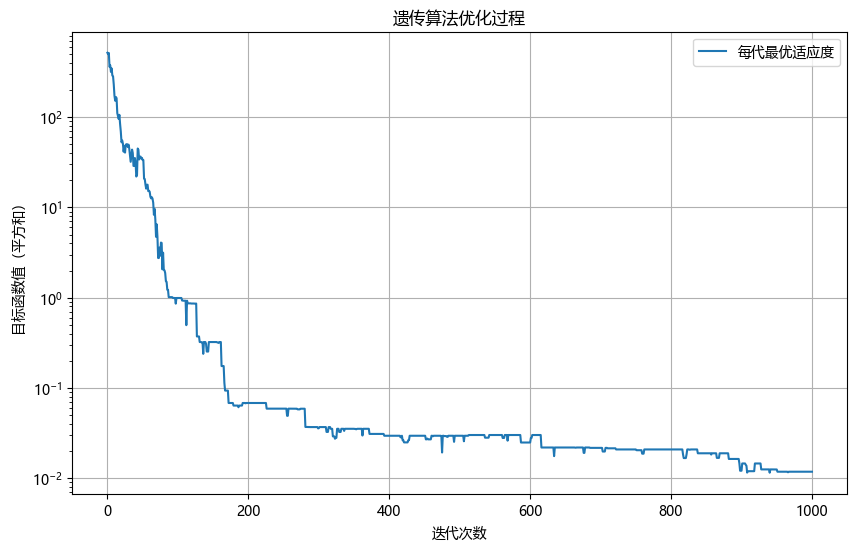

In [39]:
ga.plot_history()